## LOAD PACKAGE

In [1]:
#| export

# import kagglehub
# !pip install peft

import os
import io
import re
import random
import base64
from io import BytesIO

import time
from datetime import timedelta

import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from IPython.display import SVG

from PIL import Image


import cv2


from diffusers import StableDiffusionPipeline
from transformers import AutoProcessor, AutoModel
import metric


c:\Users\YongsanHuang\.conda\envs\sd\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.05s/it]


decoded text =  100
decoded text =  100
Does <image> portray "SVG illustration of a red circle" without any lettering? Answer yes or no.
decoded text =  100
decoded text =  100


## Competition Metric Helpers

We also want to evaluate metrics of the original bitmap before converting to svg. Let’s implement it using [metric package](https://www.kaggle.com/code/jiazhuang/svg-image-fidelity).

In [2]:
import numpy as np
import statistics
import pandas as pd

def image_resize(image, size=(384, 384)):
    return image.convert('RGB').resize(size)

def bitmap_score_instance_impl(multiple_choice_qa, image, random_seed=42):
    rng = np.random.RandomState(random_seed)
    group_seed = rng.randint(0, np.iinfo(np.int32).max)
    image_processor = metric.ImageProcessor(image=image_resize(image), seed=group_seed).apply()
    image = image_processor.image.copy()
    questions = multiple_choice_qa['question']
    choices = multiple_choice_qa['choices']
    answers = multiple_choice_qa['answer']
    aesthetic_score = metric.aesthetic_evaluator.score(image)
    vqa_score = metric.vqa_evaluator.score(questions, choices, answers, image)
    image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
    ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    instance_score = metric.harmonic_mean(vqa_score, aesthetic_score, beta=0.5) * ocr_score
    return instance_score, vqa_score, ocr_score, aesthetic_score

def bitmap_score_instance(multiple_choice_qa, image, random_seed=42):
    is_single = not isinstance(image, list)
    if is_single:
        multiple_choice_qa = [multiple_choice_qa]
        image = [image]
    
    assert len(multiple_choice_qa) == len(image)

    results = []
    score_df = []
    for one_image, one_multiple_choice_qa in zip(image, multiple_choice_qa, strict=True):
        instance_score, vqa_score, ocr_score, aesthetic_score = bitmap_score_instance_impl(one_multiple_choice_qa, one_image, random_seed=42)
        results.append(instance_score)
        score_df.append([instance_score, vqa_score, ocr_score, aesthetic_score])

    fidelity = statistics.mean(results)
    score_df = pd.DataFrame(score_df, columns=['competition_score', 'vqa_score', 'ocr_score', 'aesthetic_score'])
    if is_single:
        return score_df.iloc[0].to_dict()
    else:
        return float(fidelity), score_df

## Load SDXL

In [3]:
# %%time
# #| export

# # Ensure GPU is being used and optimize for speed
# # device = "cuda:0" if torch.cuda.is_available() else "cpu"
# # print(f"Using device: {device}")


# import torch
# from diffusers import StableDiffusionPipeline, DDIMScheduler, StableDiffusionXLPipeline
# from diffusers import AutoPipelineForText2Image
# from diffusers.utils import load_image
# from diffusers import StableDiffusionXLPipeline, LCMScheduler
# from diffusers.utils import load_image
# from diffusers.utils.import_utils import is_xformers_available


# # sdxl =============================================================
# sd_path = "stable-diffusion-xl-base-1.0"
# scheduler = DDIMScheduler.from_pretrained(sd_path, subfolder="scheduler")

# pipe = StableDiffusionXLPipeline.from_pretrained(
#     sd_path,
#     torch_dtype=torch.float16,
#     scheduler=scheduler,
#     variant = "fp16",
#     use_safetensors=True
# )
# pipe.to("cuda:0")



# # add lora ====================================================

# # # Load LoRA weights (local path or Hugging Face repo ID)
# # pipe.load_lora_weights("lora", weight_name="Luminescent_impasto_sdxl.safetensors")

# # # To activate LoRA: specify `scale` (0.0 to 1.0, default 1.0)
# # pipe.fuse_lora(lora_scale=0.8)

# # When using torch >= 2.0, you can improve the inference speed by 20-30% with torch.compile
# # but this is linux only becuase it requires triton
# # pipe.unet = torch.compile(pipe.unet, mode="reduce-overhead", fullgraph=True)

# # generate bitmap ====================================================
# # for sdxl(not turbo version), use 768 - 1024 for best quality

# def generate_bitmap(prompt, negative_prompt="", size = 768, num_inference_steps=25, guidance_scale=20):
        
#     image = pipe(
#         prompt=prompt, #to OPAI CLIP-ViT/L-14, for comma separated prompts
#         # prompt_2=prompt, #to OpenCLIP-ViT/bigG-14, for sentence
#         negative_prompt=negative_prompt,
#         num_inference_steps=num_inference_steps, 
#         guidance_scale=guidance_scale,
#         height=size,
#         width=size,
#     ).images[0]
    
#     return image

## LOAD SDXL TURBO

In [27]:
%%time
#| export

# Ensure GPU is being used and optimize for speed
# device = "cuda:0" if torch.cuda.is_available() else "cpu"
# print(f"Using device: {device}")


import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, StableDiffusionXLPipeline
from diffusers import AutoPipelineForText2Image
from diffusers.utils import load_image
from diffusers import StableDiffusionXLPipeline, LCMScheduler
from diffusers.utils import load_image
from diffusers.utils.import_utils import is_xformers_available


# sdxl =============================================================
sd_path = "sdxl-turbo"
scheduler = DDIMScheduler.from_pretrained(sd_path, subfolder="scheduler")
pipe = StableDiffusionXLPipeline.from_pretrained(
    "sdxl-turbo",
    torch_dtype=torch.float16,
    scheduler=scheduler,
    variant = "fp16",
    use_safetensors=True
)


# add lora ====================================================

# Load LoRA weights (local path or Hugging Face repo ID)
# pipe.load_lora_weights("lora", weight_name="Luminescent_impasto_sdxl.safetensors")

# move to device
pipe.to("cuda:0")

# To activate LoRA: specify `scale` (0.0 to 1.0, default 1.0)
# pipe.fuse_lora(lora_scale=0.8)

# When using torch >= 2.0, you can improve the inference speed by 20-30% with torch.compile
# but this is linux only becuase it requires triton
# pipe.unet = torch.compile(pipe.unet, mode="reduce-overhead", fullgraph=True)

# generate bitmap ====================================================
# for sdxl-turbo, use 512 for best quality
def generate_bitmap(prompt, negative_prompt="", size = 512, num_inference_steps=4, guidance_scale=0):
        
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=num_inference_steps, 
        guidance_scale=guidance_scale,
        height=size,
        width=size,
    ).images[0]
    
    return image

pipe

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 16.07it/s]


CPU times: total: 2.72 s
Wall time: 5.55 s


StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "sdxl-turbo",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

## Load Data

In [5]:
import pandas as pd
import json

In [6]:
train_df = pd.read_csv('train.csv')
train_question_df = pd.read_parquet('questions.parquet')

In [7]:
train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))
train_question_df = train_question_df.reset_index(name='qa')

train_question_df['question'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['question'], ensure_ascii=False))

train_question_df['choices'] = train_question_df.qa.apply(
    lambda qa: json.dumps(
        [x.tolist() for x in qa['choices']], ensure_ascii=False
    )
)

train_question_df['answer'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['answer'], ensure_ascii=False))

train_df = pd.merge(train_df, train_question_df, how='left', on='id')

train_df['multiple_choice_qa'] = train_df.apply(
    lambda r: {
    'question': json.loads(r.question),
    'choices': json.loads(r.choices),
    'answer': json.loads(r.answer)
    },
    axis=1,
)

train_df.head()

C:\Users\YongsanHuang\AppData\Local\Temp\ipykernel_38448\3218796089.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))


,id,description,qa,question,choices,answer,multiple_choice_qa
0,02d892,a purple forest at dusk,"{'id': ['02d892', '02d892', '02d892', '02d892'...","[""What is the main setting of the image?"", ""Is...","[[""beach"", ""desert"", ""forest"", ""mountain""], [""...","[""forest"", ""yes"", ""dusk"", ""purple""]",{'question': ['What is the main setting of the...
1,0dcd2e,gray wool coat with a faux fur collar,"{'id': ['0dcd2e', '0dcd2e', '0dcd2e', '0dcd2e'...","[""What color is the coat?"", ""What part of the ...","[[""blue"", ""brown"", ""gray"", ""red""], [""collar"", ...","[""gray"", ""collar"", ""no"", ""wool""]","{'question': ['What color is the coat?', 'What..."
2,1e9ac1,a lighthouse overlooking the ocean,"{'id': ['1e9ac1', '1e9ac1', '1e9ac1', '1e9ac1'...","[""Is there an ocean visible in the image?"", ""W...","[[""no"", ""yes""], [""inside"", ""next to"", ""overloo...","[""yes"", ""overlooking"", ""no"", ""no""]",{'question': ['Is there an ocean visible in th...
3,2b25db,burgundy corduroy pants with patch pockets and...,"{'id': ['2b25db', '2b25db', '2b25db', '2b25db'...","[""Are the pants yellow?"", ""Do the pants have p...","[[""no"", ""yes""], [""no"", ""yes""], [""no"", ""yes""], ...","[""no"", ""yes"", ""yes"", ""pants""]","{'question': ['Are the pants yellow?', 'Do the..."
4,4e6a54,orange corduroy overalls,"{'id': ['4e6a54', '4e6a54', '4e6a54', '4e6a54'...","[""What material is the item?"", ""Is a hat depic...","[[""corduroy"", ""denim"", ""leather"", ""silk""], [""n...","[""corduroy"", ""no"", ""yes"", ""overalls""]","{'question': ['What material is the item?', 'I..."


# FUNCTION img -> svg

In [8]:
import re
import vtracer
from IPython.display import SVG, display, Image
from PIL import Image as PILImage
input_path = "output.png"
output_path = "output.svg"

In [9]:
def convert_paths_to_polygons(svg_code: str, size: int) -> str:
    # Find all path elements
    scale_factor = 384 / size

    path_pattern = re.compile(
        r'<path[^>]*d="([^"]+)"[^>]*fill="([^"]+)"[^>]*transform="translate\(([^)]+)\)"[^>]*/?>'
    )
    paths = path_pattern.findall(svg_code)

    polygons = []

    for d_content, fill_color, translate in paths:
        tx, ty = map(float, translate.split(','))
        points = []
        tokens = re.findall(r'[MLZmlz]|-?\d+\.?\d*,\-?\d+\.?\d*', d_content.strip())
        for token in tokens:
            if token in {'M', 'L', 'Z', 'm', 'l', 'z'}:
                continue
            x_str, y_str = token.split(',')
            x = int(round(float(x_str) + tx))
            y = int(round(float(y_str) + ty))
            points.append(f"{x},{y}")

        if points:
            polygon = f'<polygon points="{" ".join(points)}" fill="{fill_color}"/>'
            polygons.append(polygon)

    # Build the compact SVG
    new_svg = (
        f'<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale({scale_factor})">'
        + "".join(polygons)
        + '</g></svg>'
    )

    return new_svg


def fix_svg_size(svg_code: str, target_size: int = 384) -> str:
    """
    Update the <svg> tag's width and height to match target size.
    """
    # Replace width attribute
    svg_code = re.sub(
        r'(width\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    # Replace height attribute
    svg_code = re.sub(
        r'(height\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    return svg_code




def bitmap_to_svg_layered(img, input_path, output_path):
    
    # Define input and output paths
    # (input_path and output_path are already passed as arguments)

    # Step 1: Resize the input image to 256x256
    # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
    size = 128
    img = img.resize((size,size), PILImage.LANCZOS)
    img.save(input_path)

    # Step 2: Convert the resized image to SVG
    layer_difference = 10  # initial value
    max_svg_length = 9996  # target length limit

    # Define injection to prevent OCR hallucination
    injection = '\n<path d="M5 374 L10 364 L15 374 M7 368 L13 368" stroke="white"/>'
    injection_length = len(injection)

    while True:
        vtracer.convert_image_to_svg_py(
            input_path,
            output_path,
            colormode='color',        # Options: 'color' or 'binary'
            hierarchical='stacked',   # Options: 'stacked' or 'cutout'
            mode='polygon',           # Options: 'spline', 'polygon', or 'none'
            filter_speckle=3,          # remove tiny regions
            color_precision=8,         # reduce color complexity
            layer_difference=layer_difference,  # more aggressive merging
            corner_threshold=10,       # remove subtle corners
            length_threshold=10,       # remove short paths
            max_iterations=10,         # faster, less detail
            splice_threshold=10,       # simplify curves
            path_precision=3           # reduce vertex detail
        )

        # Step 3: Read and display the SVG
        try:
            with open(output_path, "r", encoding="utf-8") as f:
                svg_code = f.read()
        except UnicodeDecodeError:
            # Bad SVG output (probably corrupted), try again
            continue  # go back to start of while loop

        # Clean the first two lines if present
        lines = svg_code.splitlines()
        removed_length = 0
        if lines and lines[0].strip().startswith('<?xml'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        if lines and lines[0].strip().startswith('<!--'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        svg_code = "\n".join(lines)

        svg_code = svg_code.replace(
            '<svg ',
            '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
            1  # only replace first occurrence
        )
        
        # remove version and xmlns attributes
        svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
        svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)

        # use polygon instead of path
        svg_code = convert_paths_to_polygons(svg_code, size)
            
        # Correct length check: give credit for removed lines
        if len(svg_code) + injection_length <= max_svg_length: # acount for injection
            break
        else:
            layer_difference += 10

    svg_code = fix_svg_size(svg_code, target_size=384) # doesnt change length

    # Inject fake letter path to prevent OCR hallucination
    svg_code = svg_code.replace("</svg>", injection + "</svg>")

    print(f'{layer_difference=}')
      

    return svg_code

# SD evaluator

In [10]:
# | export
def get_aes_and_ocr_score(svg_content):
    image_processor = metric.ImageProcessor(image=metric.svg_to_png(svg_content), seed=42).apply()
    image = image_processor.image.copy()
    aesthetic_score = metric.aesthetic_evaluator.score(image)
    image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
    ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    return aesthetic_score, ocr_score

# def get_aes_and_ocr_score(svg_content):
#     image_processor = metric.ImageProcessor(image=metric.svg_to_png(svg_content), seed=42).apply()
#     image = image_processor.image.copy()
#     aesthetic_score = metric.aesthetic_evaluator.score(image)
#     image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
#     ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
#     return aesthetic_score, ocr_score


## Implement the package Model class

In [11]:
#| export

class Model:
    # def __init__(self):
    #     self.default_svg = """<svg width="384" height="384" viewBox="0 0 384 384"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""
    #     self.prompt_prefix = "a stylized digital painting presenting a"
    #     self.prompt_suffix = " from distance. The painting promote low-poly aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, documentary, masterpiece."
    #     self.negative_prompt = 'text, logo, mirror reflection, high-reflective, lines, deformed, ugly, wrong proportion, low res, bad anatomy, worst quality, low quality, framing, hatching, textures, patterns, outlines'
    #     self.num_inference_steps = 20
    #     self.guidance_scale = 20
    #     self.num_attempt = 10
    
    def __init__(self):

        self.default_svg = """<svg width="384" height="384" viewBox="0 0 384 384"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""
        self.prompt_prefix = "Simple, classic image of"
        self.prompt_suffix = "with flat color blocks, beautiful, minimal details, solid colors only"
        self.negative_prompt = "text, signature, framing, hatching, background, textures, patterns, lines, outlines"
        # self.num_inference_steps = 25
        # self.guidance_scale = 20
        self.num_attempt = 5

    def gen_bitmap(self, description):
        prompt = f'{self.prompt_prefix} {description}{self.prompt_suffix}'
        bitmap = generate_bitmap(prompt = prompt, negative_prompt=self.negative_prompt)
        return bitmap

    def predict_impl(self, prompt: str) -> str:
        best_score = 0.0
        best_svg = None
        best_img = None
        print(f'======= {prompt} =======')
        for i in range(self.num_attempt):
            bitmap = self.gen_bitmap(prompt)
            svg = bitmap_to_svg_layered(bitmap, input_path, output_path)
            aesthetic_score, ocr_score = get_aes_and_ocr_score(svg)
            score = aesthetic_score * ocr_score
            print(f'{score=}')
            print('svg length:', len(svg))
            if score >= best_score:
                best_score = score
                best_svg = svg
                best_img = bitmap
                # print('update score:', best_score)
        print('final score:', best_score)
        print('=======================================================================')
        
        if best_svg is None:
            best_svg = self.default_svg

        return best_svg, best_img

    def predict(self, prompt: str) -> str:
        svg, img = self.predict_impl(prompt)
        return svg

In [12]:
model = Model()

======= magenta trapezoids layered on a transluscent silver sheet =======


100%|██████████| 4/4 [00:00<00:00, 10.92it/s]


layer_difference=100
decoded text =  A
score=0.4650400638580322
svg length: 9034


100%|██████████| 4/4 [00:00<00:00, 19.12it/s]


layer_difference=80
decoded text =  A
score=0.4295849323272705
svg length: 9971


...

layer_difference=120
decoded text =  A
score=0.4251872539520264
svg length: 9482


100%|██████████| 4/4 [00:00<00:00, 18.66it/s]


layer_difference=110
decoded text =  A
score=0.43903818130493166
svg length: 9289


100%|██████████| 4/4 [00:00<00:00, 19.00it/s]


layer_difference=100
decoded text =  A
score=0.42546510696411133
svg length: 9046
final score: 0.4650400638580322


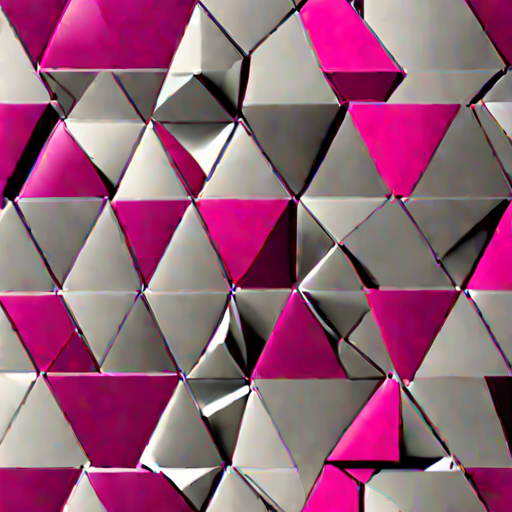

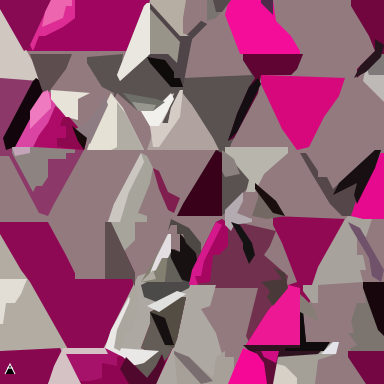

<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="0,0 128,0 128,128 0,128" fill="#927A7F"/><polygon points="0,74 16,74 22,85 25,91 25,93 35,93 35,74 37,74 45,91 44,98 35,116 41,118 44,121 48,120 51,118 47,116 50,108 50,104 60,99 62,99 59,113 52,128 0,128" fill="#B2ACA3"/><polygon points="50,1 57,7 62,12 67,7 69,8 64,13 61,26 84,25 81,20 81,18 101,18 99,23 97,25 87,25 86,31 77,48 76,52 83,58 84,61 75,71 74,72 59,72 61,68 72,50 67,41 60,32 56,41 54,41 56,35 56,33 51,37 46,37 39,31 38,33 38,31 34,29 29,21 29,19 41,18 40,26 49,18 56,18 59,21 60,14 50,3" fill="#5A5250"/><polygon points="0,74 16,74 22,85 25,91 25,93 35,93 35,74 37,74 45,91 44,98 34,117 23,117 10,94 7,90 0,78" fill="#8E0953"/><polygon points="74,73 77,75 79,74 92,77 90,82 88,85 96,92 95,97 83,114 82,112 86,96 63,96 53,101 48,99 47,95 49,94 55,94 56,84 58,83 60,84 60,78 65,83 67,84 72,74" fill="#71304E"/><polygon points="0,0 50,0 43,17 8,17 0,3" fill="#A00660"/><polygon points="56,7

In [13]:
%%time
r = train_df.iloc[9]
description = r.description
svg, img = model.predict_impl(description)
display(img)
display(SVG(svg))
print(svg)

In [14]:
metric.score_instance(r.multiple_choice_qa, svg, random_seed=42)

decoded text =  A


{'competition_score': 0.23140588389357444,
 'vqa_score': 0.20580629854371132,
 'ocr_score': 1.0,
 'aesthetic_score': 0.460552453994751}

## Evaluate on train dataset (LB prediction!)

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

In [16]:
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

In [17]:
train_df.head()

,id,description,qa,question,choices,answer,multiple_choice_qa
0,02d892,a purple forest at dusk,"{'id': ['02d892', '02d892', '02d892', '02d892'...","[""What is the main setting of the image?"", ""Is...","[[""beach"", ""desert"", ""forest"", ""mountain""], [""...","[""forest"", ""yes"", ""dusk"", ""purple""]",{'question': ['What is the main setting of the...
1,0dcd2e,gray wool coat with a faux fur collar,"{'id': ['0dcd2e', '0dcd2e', '0dcd2e', '0dcd2e'...","[""What color is the coat?"", ""What part of the ...","[[""blue"", ""brown"", ""gray"", ""red""], [""collar"", ...","[""gray"", ""collar"", ""no"", ""wool""]","{'question': ['What color is the coat?', 'What..."
2,1e9ac1,a lighthouse overlooking the ocean,"{'id': ['1e9ac1', '1e9ac1', '1e9ac1', '1e9ac1'...","[""Is there an ocean visible in the image?"", ""W...","[[""no"", ""yes""], [""inside"", ""next to"", ""overloo...","[""yes"", ""overlooking"", ""no"", ""no""]",{'question': ['Is there an ocean visible in th...
3,2b25db,burgundy corduroy pants with patch pockets and...,"{'id': ['2b25db', '2b25db', '2b25db', '2b25db'...","[""Are the pants yellow?"", ""Do the pants have p...","[[""no"", ""yes""], [""no"", ""yes""], [""no"", ""yes""], ...","[""no"", ""yes"", ""yes"", ""pants""]","{'question': ['Are the pants yellow?', 'Do the..."
4,4e6a54,orange corduroy overalls,"{'id': ['4e6a54', '4e6a54', '4e6a54', '4e6a54'...","[""What material is the item?"", ""Is a hat depic...","[[""corduroy"", ""denim"", ""leather"", ""silk""], [""n...","[""corduroy"", ""no"", ""yes"", ""overalls""]","{'question': ['What material is the item?', 'I..."


In [18]:
%%time
train_df['raw_res'] = train_df.description.progress_apply(model.predict_impl)

  0%|          | 0/15 [00:00<?, ?it/s]

======= a purple forest at dusk =======


100%|██████████| 4/4 [00:00<00:00, 18.98it/s]


layer_difference=70
decoded text =  A
score=0.49995031356811526
svg length: 8550


100%|██████████| 4/4 [00:00<00:00, 16.96it/s]


...

layer_difference=140
decoded text =  A
score=0.4774204730987549
svg length: 9646


100%|██████████| 4/4 [00:00<00:00, 18.29it/s]


layer_difference=60


100%|██████████| 15/15 [01:17<00:00,  5.16s/it]

decoded text =  A
score=0.46353325843811033
svg length: 8225
final score: 0.4774204730987549
CPU times: total: 18.3 s
Wall time: 1min 17s


In [19]:
train_df['svg'] = train_df.raw_res.apply(lambda x: x[0])
train_df['bitmap'] = train_df.raw_res.apply(lambda x: x[1])

In [20]:
train_df['bitmap_score'] = train_df.progress_apply(
    lambda r: bitmap_score_instance(r.multiple_choice_qa, r.bitmap, random_seed=42),
    axis=1,
)

 13%|█▎        | 2/15 [00:01<00:10,  1.20it/s]

decoded text =  *


 20%|██        | 3/15 [00:03<00:13,  1.16s/it]

decoded text =  © AP


 27%|██▋       | 4/15 [00:04<00:14,  1.30s/it]

...

decoded text =  *


100%|██████████| 15/15 [00:22<00:00,  1.55s/it]

decoded text =  7


100%|██████████| 15/15 [00:23<00:00,  1.59s/it]

decoded text =  © Getty Images


In [21]:
train_df['svg_score'] = train_df.progress_apply(
    lambda r: metric.score_instance(r.multiple_choice_qa, r.svg, random_seed=42),
    axis=1,
)

 13%|█▎        | 2/15 [00:01<00:09,  1.31it/s]

decoded text =  A


 20%|██        | 3/15 [00:02<00:12,  1.05s/it]

decoded text =  A


 27%|██▋       | 4/15 [00:04<00:13,  1.21s/it]

...

decoded text =  A


100%|██████████| 15/15 [00:20<00:00,  1.49s/it]

decoded text =  A


100%|██████████| 15/15 [00:22<00:00,  1.48s/it]

decoded text =  A


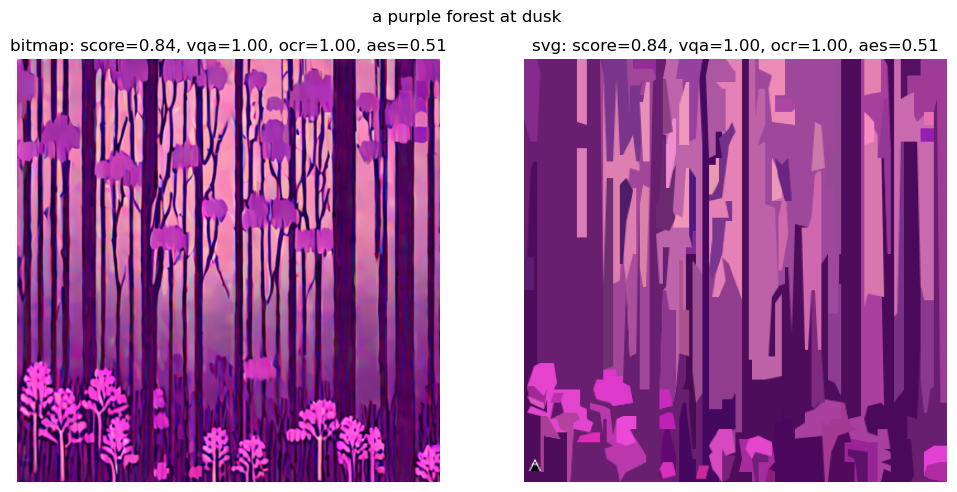

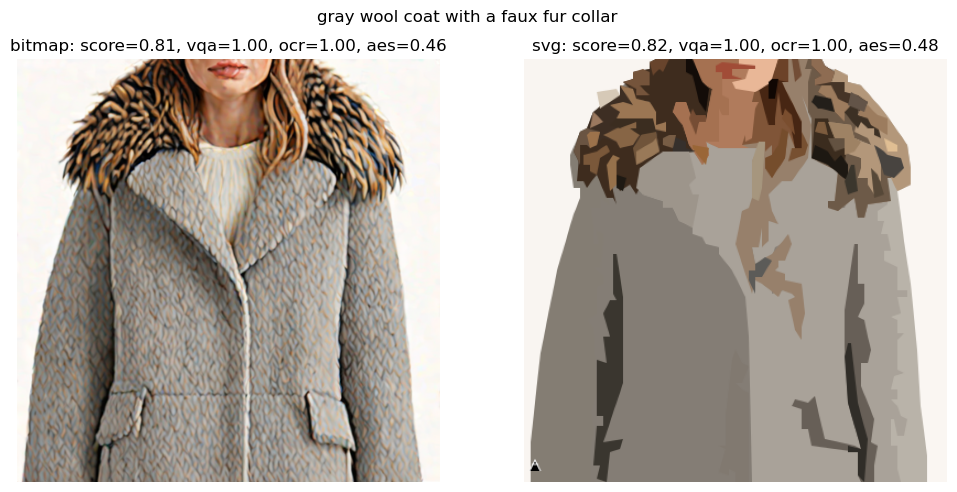

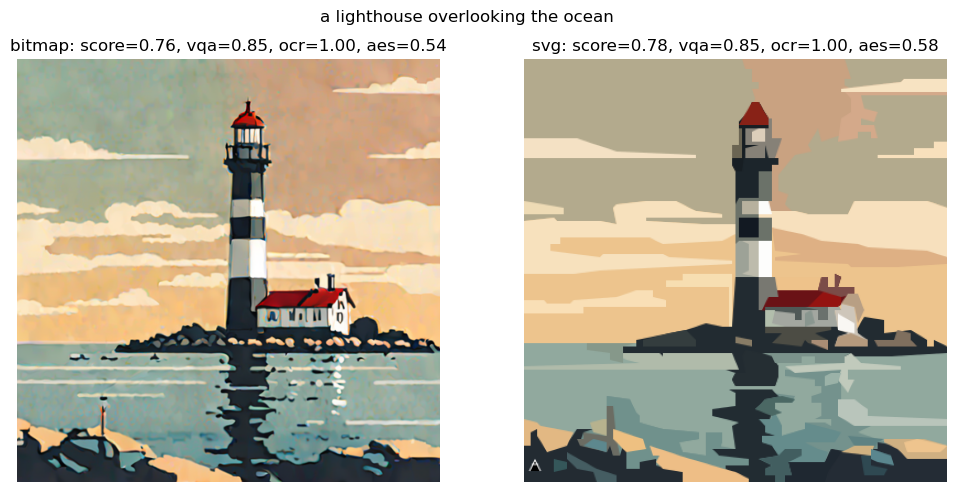

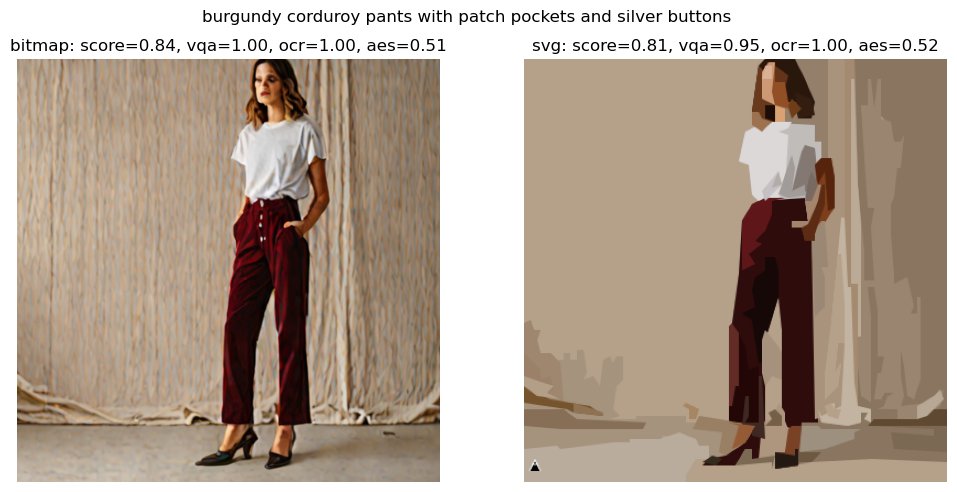

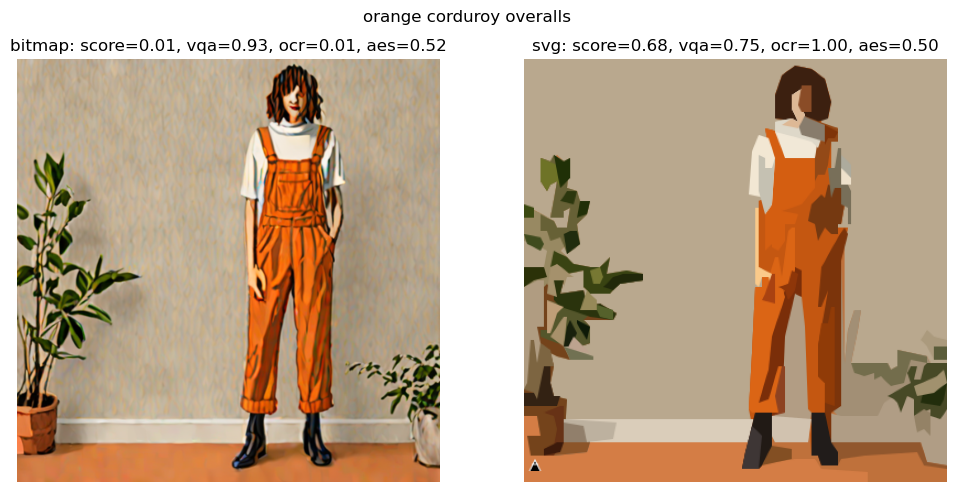

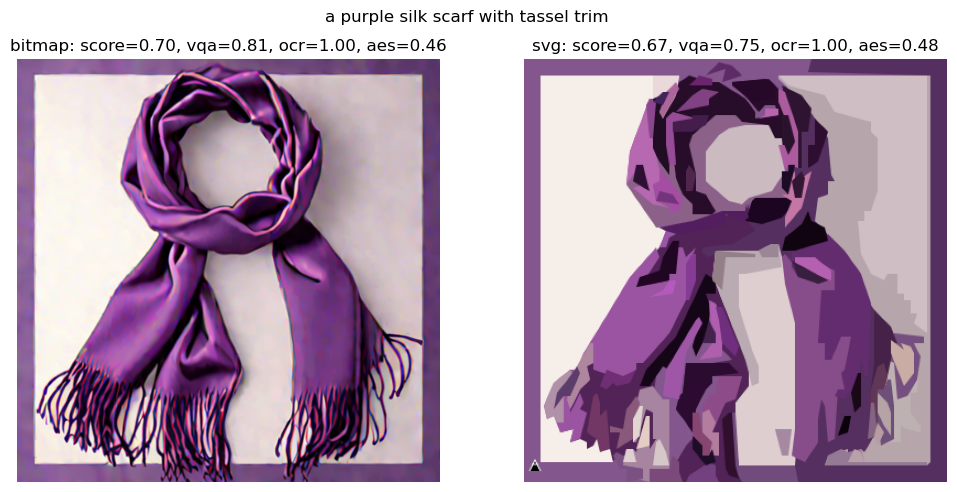

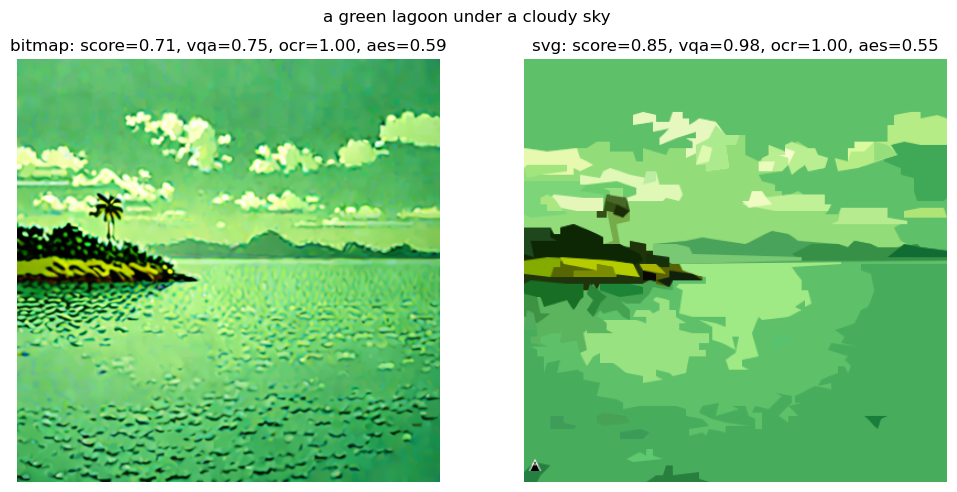

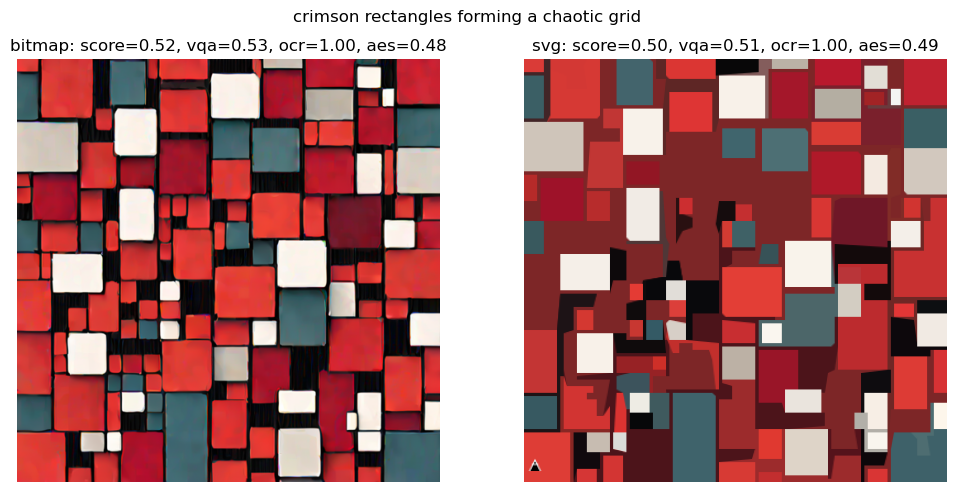

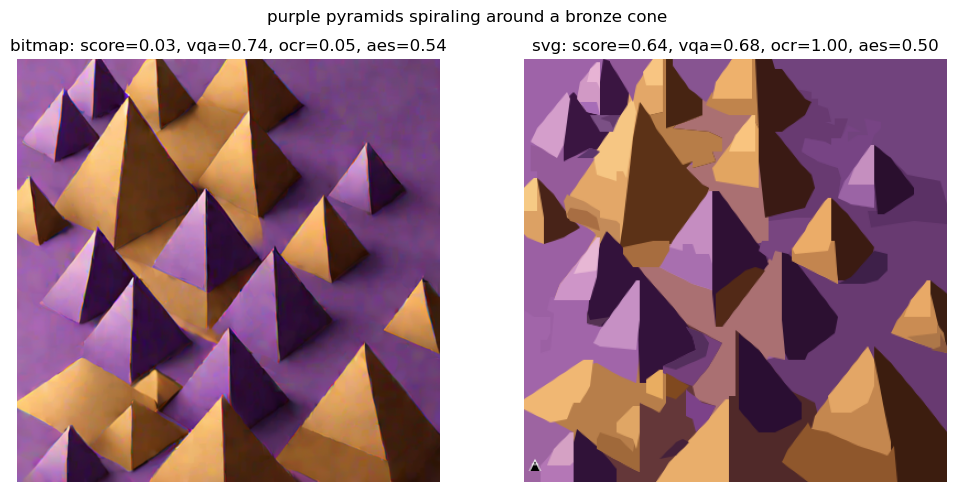

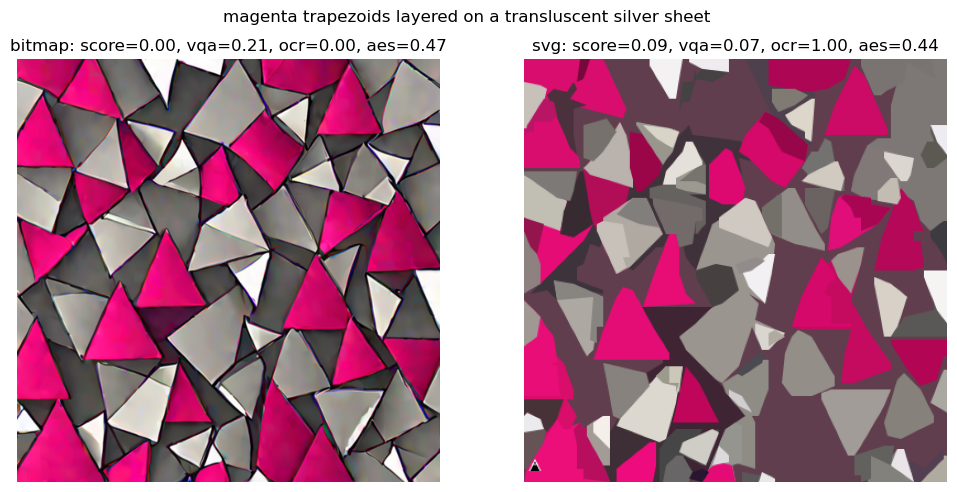

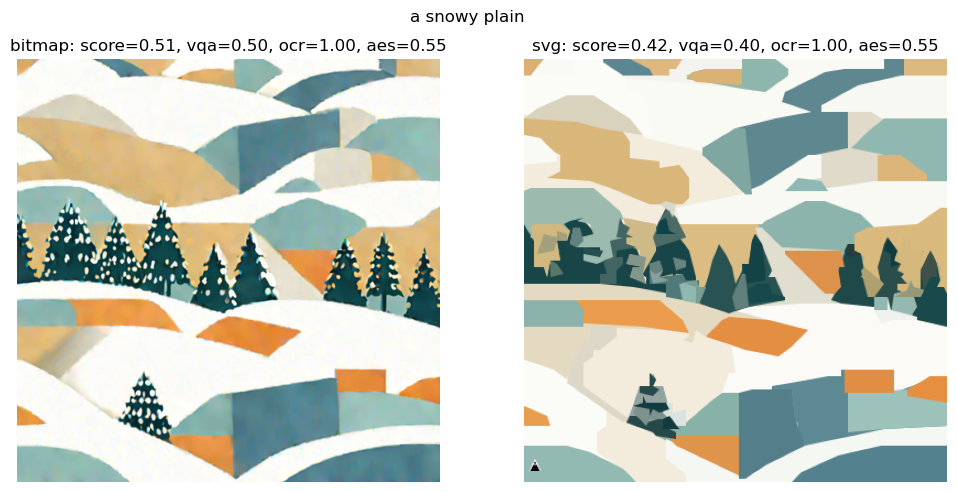

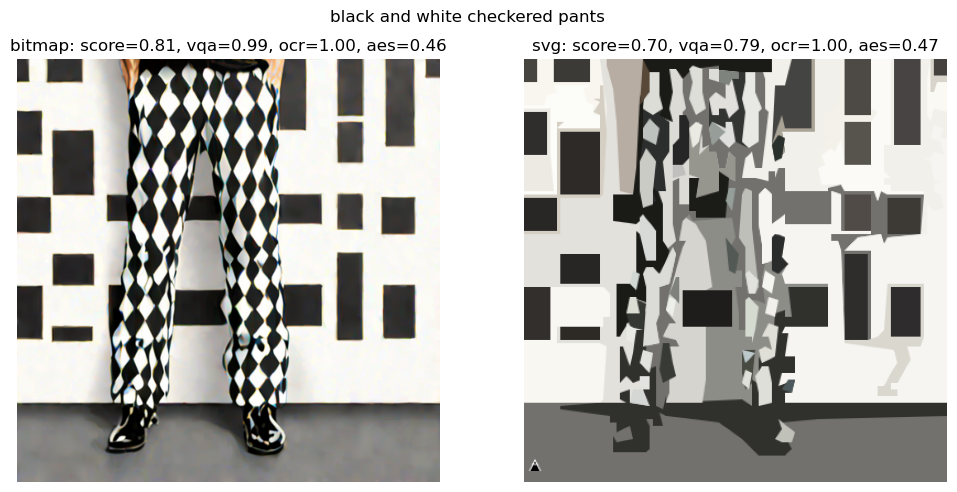

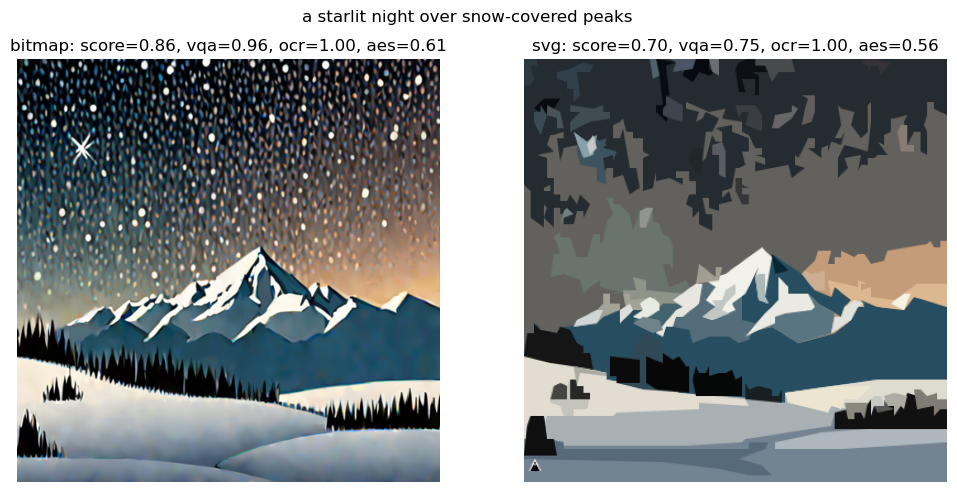

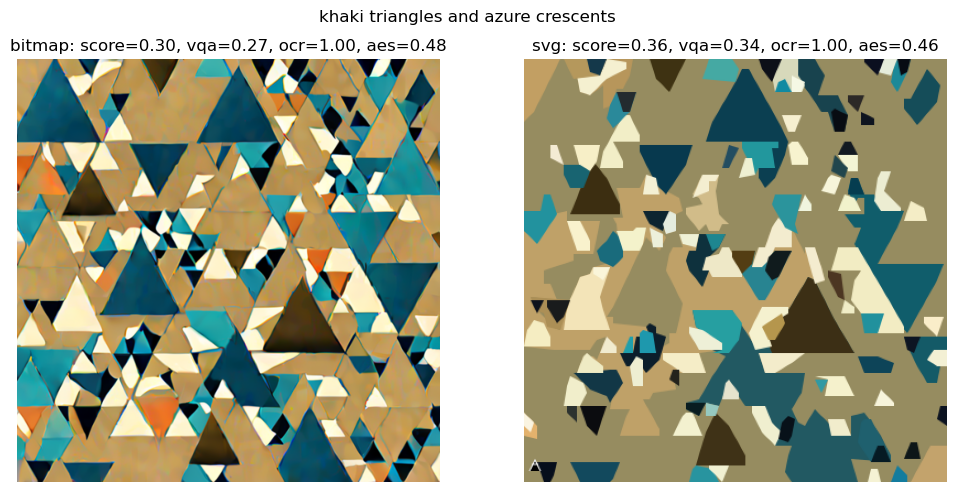

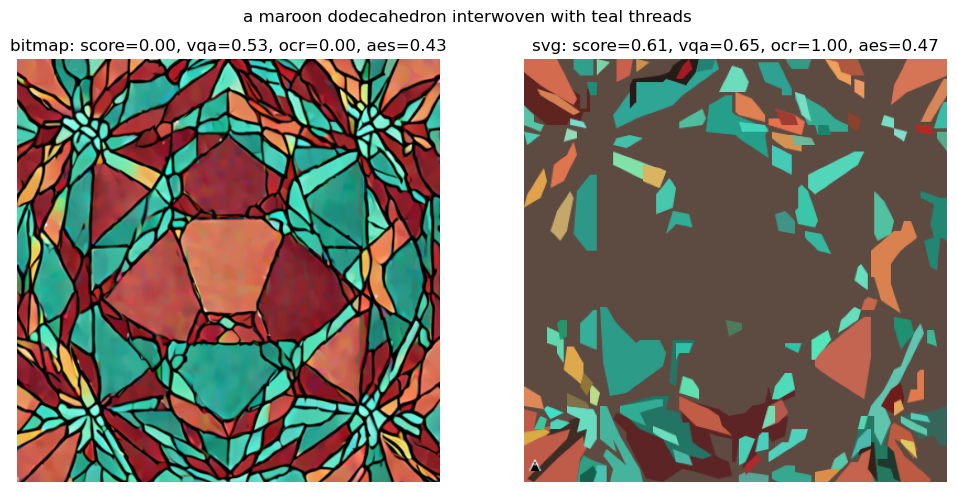

In [22]:
for r in train_df.itertuples():
    
    b_vqa = r.bitmap_score['vqa_score']
    b_aesthetic = r.bitmap_score['aesthetic_score']
    b_ocr = r.bitmap_score['ocr_score']
    b_score = r.bitmap_score['competition_score']

    
    s_vqa = r.svg_score['vqa_score']
    s_aesthetic = r.svg_score['aesthetic_score']
    s_ocr = r.svg_score['ocr_score']
    s_score = r.svg_score['competition_score']
    
    plt.figure(figsize=(12, 6))
    plt.suptitle(r.description, y=0.93)
    
    plt.subplot(1, 2, 1)
    plt.imshow(np.array(r.bitmap))
    plt.axis('off')
    plt.title(f'bitmap: score={b_score:.2f}, vqa={b_vqa:.2f}, ocr={b_ocr:.2f}, aes={b_aesthetic:.2f}')

    plt.subplot(1, 2, 2)
    plt.imshow(metric.svg_to_png(r.svg))
    plt.axis('off')
    plt.title(f'svg: score={s_score:.2f}, vqa={s_vqa:.2f}, ocr={s_ocr:.2f}, aes={s_aesthetic:.2f}')

In [23]:
mean_bitmap_score = pd.DataFrame(train_df['bitmap_score'].tolist()).mean(axis=0)
mean_bitmap_score

competition_score    0.513505
vqa_score            0.738844
ocr_score            0.737105
aesthetic_score      0.507454
dtype: float64

In [24]:
mean_svg_score = pd.DataFrame(train_df['svg_score'].tolist()).mean(axis=0)
mean_svg_score

competition_score    0.631109
vqa_score            0.698109
ocr_score            1.000000
aesthetic_score      0.503910
dtype: float64

In [25]:
print(f'Original bitmap score: {mean_bitmap_score.competition_score}')
print(f'Final svg score: {mean_svg_score.competition_score}')

Original bitmap score: 0.5135047379617877
Final svg score: 0.6311090099543096
